# 03 — Regime model

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR = (ROOT / "../data/raw").resolve()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Research parameters
REBALANCE_FREQUENCY = "ME"
VOLATILITY_WINDOW = 60
ANNUAL_VOLATILITY_TARGET = 0.10
LEVERAGE_CAP = 4.0
LONG_FRACTION = 0.30
SHORT_FRACTION = 0.30
TRANSACTION_COST_BPS = 5.0
MINIMUM_TRAINING_MONTHS = 60
PROBABILITY_THRESHOLD = 0.50
RANDOM_STATE = 42

print("Data directory:", DATA_DIR)

from src.data_loader import read_parquet
from src.features import build_monthly_state_features
from src.models import expanding_logistic_predictions


Data directory: C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\data\raw


In [2]:
static_path = OUTPUT_DIR / "static_carry_returns.csv"
if not static_path.exists():
    raise FileNotFoundError(
        "Run 02_baseline_carry.ipynb after completing the field mapping."
    )

static = pd.read_csv(
    static_path,
    index_col=0,
    parse_dates=True,
).iloc[:, 0]


In [3]:
FEATURE_FILES = {
    "global_risk": "global_risk_wide.parquet",
    "em_risk": "em_risk_wide.parquet",
    "macro_market_proxies": "macro_market_proxies_wide.parquet",
    "g10_interest_rates": "g10_interest_rates_wide.parquet",
    "em_interest_rates": "em_interest_rates_wide.parquet",
    "em_onshore_rates": "em_onshore_rates_wide.parquet",
    "g10_rates_gaps": "g10_rates_gaps_wide.parquet",
    "usd_riskfree": "usd_riskfree_wide.parquet",
}

feature_frames = []
for group_name, filename in FEATURE_FILES.items():
    path = DATA_DIR / filename
    if path.exists():
        frame = read_parquet(path)
        frame.columns = [f"{group_name}__{column}" for column in frame.columns]
        feature_frames.append(frame)

market = pd.concat(feature_frames, axis=1).sort_index()

coverage = market.notna().mean()
market = market.loc[:, coverage[coverage >= 0.60].index]

# Keep the first model interpretable and computationally manageable.
market = market.iloc[:, :80]
print("Feature panel shape:", market.shape)


Feature panel shape: (7127, 80)


In [9]:
carry_scores = pd.read_parquet(OUTPUT_DIR / "carry_scores.parquet")
carry_dispersion = carry_scores.std(axis=1)

dataset = build_monthly_state_features(
    static,
    market,
    carry_dispersion,
)

feature_columns = [
    column
    for column in dataset.columns
    if column not in {"target_next_positive", "next_return"}
]

valid_coverage = dataset[feature_columns].notna().mean().ge(0.60)
feature_columns = valid_coverage[valid_coverage].index.tolist()
feature_columns = [
    column
    for column in feature_columns
    if dataset[column].nunique(dropna=True) > 2
]

prediction = expanding_logistic_predictions(
    dataset,
    feature_columns,
    minimum_training_months=MINIMUM_TRAINING_MONTHS,
    random_state=RANDOM_STATE,
)

dataset["probability"] = prediction.probability
dataset.to_parquet(OUTPUT_DIR / "regime_dataset.parquet")
prediction.coefficients.to_csv(
    OUTPUT_DIR / "rolling_model_coefficients.csv"
)

display(dataset[["next_return", "probability"]].dropna().tail())


,next_return,probability
date,,
2026-01-31,-0.003892,0.180818
2026-02-28,0.010940,0.549255
2026-03-31,0.034189,0.354004
2026-04-30,-0.002124,0.334316
2026-05-31,-0.025549,0.338643


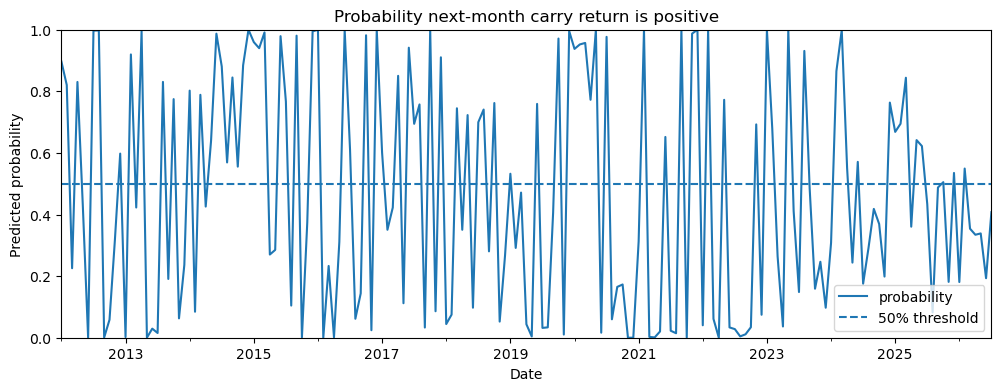

In [11]:
ax = dataset["probability"].dropna().plot(
    figsize=(12, 4),
    title="Probability next-month carry return is positive"
)

ax.axhline(
    0.5,
    linestyle="--",
    label="50% threshold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Predicted probability")
ax.set_ylim(0, 1)
ax.legend()
plt.show()